In [1]:
!nvidia-smi


Tue Apr 21 23:38:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   57C    P0             26W /   80W |      11MiB /   6144MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import tensorflow as tf
import keras
import keras_cv

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)


2026-04-21 23:38:21.411297: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 23:38:21.508558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776789501.549699   10484 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776789501.560606   10484 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776789501.635891   10484 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow version: 2.19.1


In [3]:
DATA_PATH = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/swin_ids/Preprocessing/hasil_preprocessing/prep64/swin_res64_datasetincluded_val.npz"

data = np.load(DATA_PATH)

X_train = data["X_train"]
y_train = data["y_train"]
X_test  = data["X_test"]
y_test  = data["y_test"]
X_val   = data["X_val"]
y_val   = data["y_val"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Val shape  :", X_val.shape)


Train shape: (26330, 32, 32, 3)
Test shape : (24736, 32, 32, 3)
Val shape  : (11285, 32, 32, 3)


In [4]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))
print("Val label distribution  :", np.unique(y_val, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1]), array([12040, 14290]))
Test label distribution : (array([0, 1]), array([13693, 11043]))
Val label distribution  : (array([0, 1]), array([5160, 6125]))
Min value: -0.5254788
Max value: 2.3738105


In [5]:
import torch
import torch.nn as nn
import timm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.5.1+cu121
CUDA available: True


In [6]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [7]:
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=1,
    img_size=32,   # sesuaikan dengan dataset
    window_size=8
)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
EPOCHS = 50
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)


/home/dani/miniconda3/envs/latihan1/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [8]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [9]:
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 27,499,435
Trainable params: 27,499,435


Total params: 27,499,868
Trainable params: 27,499,868

In [10]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 32, 32),   # (batch, channel, height, width)
    col_names=["input_size", "output_size", "num_params"],
    depth=3
)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
SwinTransformer                                    [1, 3, 32, 32]            [1, 1]                    --
├─PatchEmbed: 1-1                                  [1, 3, 32, 32]            [1, 8, 8, 96]             --
│    └─Conv2d: 2-1                                 [1, 3, 32, 32]            [1, 96, 8, 8]             4,704
│    └─LayerNorm: 2-2                              [1, 8, 8, 96]             [1, 8, 8, 96]             192
├─Sequential: 1-2                                  [1, 8, 8, 96]             [1, 1, 1, 768]            --
│    └─SwinTransformerStage: 2-3                   [1, 8, 8, 96]             [1, 8, 8, 96]             --
│    │    └─Identity: 3-1                          [1, 8, 8, 96]             [1, 8, 8, 96]             --
│    │    └─Sequential: 3-2                        [1, 8, 8, 96]             [1, 8, 8, 96]             225,030
│    └─SwinTransformerStage: 2-4

In [11]:
import numpy as np

# ubah dari NHWC → NCHW
X_train_pt = torch.tensor(X_train).permute(0,3,1,2).float()
X_test_pt  = torch.tensor(X_test).permute(0,3,1,2).float()
X_val_pt   = torch.tensor(X_val).permute(0,3,1,2).float()

y_train_pt = torch.tensor(y_train).float().unsqueeze(1)
y_val_pt   = torch.tensor(y_val).float().unsqueeze(1)
y_test_pt  = torch.tensor(y_test).float().unsqueeze(1)
print(X_train_pt.shape)
print(X_test_pt.shape)
print(X_val_pt.shape)

torch.Size([26330, 3, 32, 32])
torch.Size([24736, 3, 32, 32])
torch.Size([11285, 3, 32, 32])


In [12]:
from torch.utils.data import Dataset, DataLoader

class IDS_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [13]:
train_dataset = IDS_Dataset(X_train_pt, y_train_pt)
test_dataset  = IDS_Dataset(X_test_pt, y_test_pt)
val_dataset   = IDS_Dataset(X_val_pt, y_val_pt)


In [14]:


train_loader = DataLoader(
    train_dataset,
    batch_size=10,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=10,
    num_workers=4,
    pin_memory=True
)


In [15]:
device = torch.device("cuda")
model = model.to(device)

print(next(model.parameters()).device)


cuda:0


In [16]:
val_loader = DataLoader(
    val_dataset,
    batch_size=10,
    num_workers=4,
    pin_memory=True
)

In [17]:
from tqdm import tqdm

EPOCHS = 50
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ======================
    # TRAINING
    # ======================
    model.train()
    running_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(train_loss=loss.item())

    train_loss = running_loss / len(train_loader)

    # ======================
    # VALIDATION
    # ======================
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_dataset)

    # ======================
    # SCHEDULER STEP
    # ======================
    scheduler.step(val_loss)

    # ======================
    # SAVE BEST MODEL
    # ======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/50: 100%|██████████| 2633/2633 [01:03<00:00, 41.77it/s, train_loss=0.245]  


Epoch 1 | Train Loss: 0.1871 | Val Loss: 0.0091


Epoch 2/50: 100%|██████████| 2633/2633 [01:02<00:00, 42.25it/s, train_loss=0.0239]  


Epoch 2 | Train Loss: 0.0766 | Val Loss: 0.0072


Epoch 3/50: 100%|██████████| 2633/2633 [01:05<00:00, 40.45it/s, train_loss=0.064]   


...

Epoch 48 | Train Loss: 0.0009 | Val Loss: 0.0039


Epoch 49/50: 100%|██████████| 2633/2633 [01:06<00:00, 39.72it/s, train_loss=2.83e-5] 


Epoch 49 | Train Loss: 0.0011 | Val Loss: 0.0039


Epoch 50/50: 100%|██████████| 2633/2633 [01:07<00:00, 39.20it/s, train_loss=2.77e-5] 


Epoch 50 | Train Loss: 0.0013 | Val Loss: 0.0039


In [18]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        y_pred = (probs >= 0.5).int()

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


/tmp/ipykernel_10484/4094245609.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_prob = np.array(all_probs).reshape(-1)
y_true = np.array(all_labels)

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)

TP: 8375
FP: 360
TN: 13333
FN: 2668


th 0.5


In [20]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        y_pred = (probs >= 0.5).int()

        all_preds.extend(y_pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
FPR = FP / (FP + TN + 1e-8)
FNR = FN / (FN + TP + 1e-8)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("FPR:", FPR)
print("FNR:", FNR)


Accuracy: 0.8775873221216042
Precision: 0.9587864911265497
Recall: 0.758398985782162
F1: 0.8469005916897424
FPR: 0.026290805521049957
FNR: 0.24160101421693234


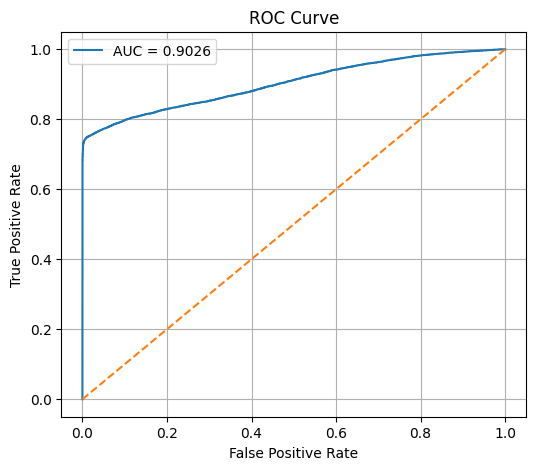

In [21]:
from sklearn.metrics import roc_curve, auc

fpr_curve, tpr_curve, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(6,5))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


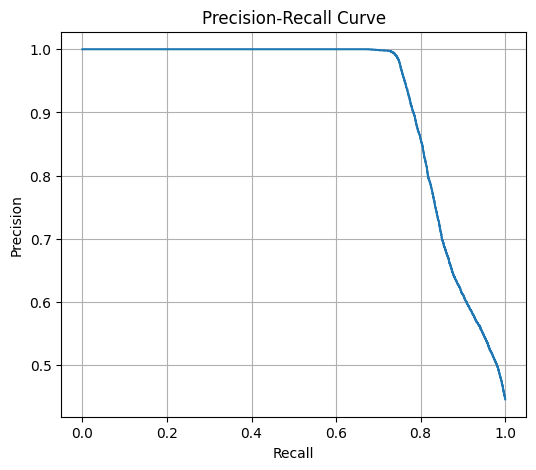

In [22]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()


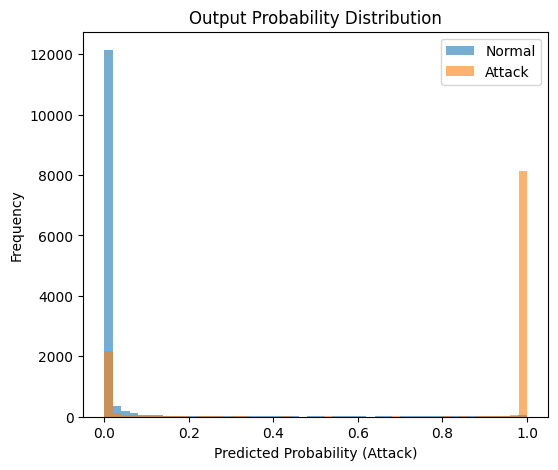

In [23]:
y_prob = np.array(all_probs).reshape(-1)
y_true = np.array(all_labels).reshape(-1)

normal_probs = y_prob[y_true == 0]
attack_probs = y_prob[y_true == 1]

plt.figure(figsize=(6,5))
plt.hist(normal_probs, bins=50, alpha=0.6, label="Normal")
plt.hist(attack_probs, bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Output Probability Distribution")
plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.show()


th bestth


In [24]:
best_threshold = 0
best_f1 = -1

target_fpr = 0.01  # bisa kamu ubah sesuai kebutuhan IDS

best_metrics = None

for t in thresholds:
    preds = (np.array(all_probs) >= t).astype(int)
    cm = confusion_matrix(all_labels, preds)

    if cm.shape != (2,2):
        continue

    TN, FP, FN, TP = cm.ravel()

    fpr = FP / (FP + TN + 1e-8)

    # 🔴 constraint IDS
    if fpr <= target_fpr:

        precision = TP / (TP + FP + 1e-8)
        recall    = TP / (TP + FN + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        accuracy  = (TP + TN) / (TP + TN + FP + FN)
        fnr       = FN / (FN + TP + 1e-8)

        # 🔴 maximize F1 under constraint
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

            best_metrics = {
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "FPR": fpr,
                "FNR": fnr,
                "FP": FP,
                "FN": FN
            }

print("Best Threshold (FPR constrained):", best_threshold)
print("Metrics at that threshold:")
for k, v in best_metrics.items():
    print(k, ":", v)

Best Threshold (FPR constrained): 0.9104158
Metrics at that threshold:
Accuracy : 0.8817917205692108
Precision : 0.9848321987328498
Recall : 0.7467173775235473
F1 : 0.8494025496878267
FPR : 0.009274811947703736
FNR : 0.2532826224755471
FP : 127
FN : 2797


In [25]:
print("y_prob shape:", y_prob.shape)
print("y_true shape:", y_true.shape)

y_prob shape: (24736,)
y_true shape: (24736,)
